<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/prediksi_harga_hasil_tani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A. Persiapan & Load Dataset


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
data = pd.read_csv("harga_pertanian.csv")

print("Preview data:")
# Format 'jumlah' to Rupiah
data['jumlah_Formatted'] = (data['jumlah']).apply(lambda x: f'Rp {x:,.2f}')
print("Columns in DataFrame:", data.columns)
print(data[['nama_provinsi', 'nama_kabupaten_kota', 'periode_update', 'jumlah_Formatted', 'satuan', 'kategori']].head())

print("\nInfo kolom:")
print(data.info())

print("\nStatistik deskriptif:")
print(data.describe(include='all'))

print("\nChecking for missing values:")
print(data.isnull().sum())

Preview data:
Columns in DataFrame: Index(['id', 'id_index', 'kode_provinsi', 'nama_provinsi',
       'kode_kabupaten_kota', 'nama_kabupaten_kota', 'periode_update',
       'kategori', 'jumlah', 'satuan', 'tahun', 'jumlah_Formatted'],
      dtype='object')
  nama_provinsi nama_kabupaten_kota periode_update jumlah_Formatted satuan  \
0    JAWA TIMUR   KABUPATEN PACITAN        2020-01      Rp 8,500.00  RP/KG   
1    JAWA TIMUR   KABUPATEN PACITAN        2020-01     Rp 10,500.00  RP/KG   
2    JAWA TIMUR   KABUPATEN PACITAN        2020-01      Rp 5,500.00  RP/KG   
3    JAWA TIMUR   KABUPATEN PACITAN        2020-01          Rp 0.00  RP/KG   
4    JAWA TIMUR   KABUPATEN PACITAN        2020-01      Rp 4,200.00  RP/KG   

              kategori  
0         BERAS MEDIUM  
1        BERAS PREMIUM  
2  GABAH KERING GILING  
3   GABAH KERING PANEN  
4  JAGUNG PIPIL KERING  

Info kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15276 entries, 0 to 15275
Data columns (total 12 columns):
 #

In [ ]:
# Calculate the mean of the 'jumlah' column
mean_jumlah = data['jumlah'].mean()

# Round the mean to the nearest integer
rounded_mean_jumlah = round(mean_jumlah)

# Count the number of zeros in the 'jumlah' column before replacement
zero_count_before = (data['jumlah'] == 0).sum()

# Replace the 0 values in the 'jumlah' column with the rounded mean
data['jumlah_replaced_zeros'] = data['jumlah'].replace(0, rounded_mean_jumlah)

# Count the number of zeros in the new column after replacement (should be 0)
zero_count_after = (data['jumlah_replaced_zeros'] == 0).sum()

print(f"Jumlah nilai 0 sebelum penggantian: {zero_count_before}")
print(f"Rata-rata dari kolom 'jumlah' (dibulatkan): {rounded_mean_jumlah}")
print(f"Jumlah nilai 0 setelah penggantian: {zero_count_after}")

# Display the rows where 'jumlah' was originally 0, showing the replaced value
print("\nData dengan nilai 0 di kolom 'jumlah' yang sudah diubah:")
display(data[data['jumlah'] == 0][['periode_update', 'kategori', 'jumlah', 'jumlah_replaced_zeros']].head())

Jumlah nilai 0 sebelum penggantian: 5623
Rata-rata dari kolom 'jumlah' (dibulatkan): 4851
Jumlah nilai 0 setelah penggantian: 0

Data dengan nilai 0 di kolom 'jumlah' yang sudah diubah:


,periode_update,kategori,jumlah,jumlah_replaced_zeros
3,2020-01,GABAH KERING PANEN,0,4851
5,2020-01,KEDELAI,0,4851
23,2020-01,KEDELAI,0,4851
29,2020-01,KEDELAI,0,4851
47,2020-01,KEDELAI,0,4851


In [ ]:
# Calculate the correlation matrix
correlation_matrix = data.corr(numeric_only=True)

# Display the correlation matrix
display(correlation_matrix)

,id,id_index,kode_provinsi,kode_kabupaten_kota,jumlah,tahun,jumlah_replaced_zeros
id,1.000000,0.967349,NaN,7.573092e-03,0.091800,9.844133e-01,0.201298
id_index,0.967349,1.000000,NaN,6.377361e-03,0.101445,9.565236e-01,0.205740
kode_provinsi,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kode_kabupaten_kota,0.007573,0.006377,NaN,1.000000e+00,-0.365324,1.246322e-13,-0.218323
jumlah,0.091800,0.101445,NaN,-3.653243e-01,1.000000,1.015162e-01,0.887194
tahun,0.984413,0.956524,NaN,1.246322e-13,0.101516,1.000000e+00,0.205836
jumlah_replaced_zeros,0.201298,0.205740,NaN,-2.183228e-01,0.887194,2.058359e-01,1.000000


In [ ]:
price_correlation = correlation_matrix['jumlah_replaced_zeros'].sort_values(ascending=False)
display(price_correlation)

,jumlah_replaced_zeros
jumlah_replaced_zeros,1.000000
jumlah,0.887194
tahun,0.205836
id_index,0.205740
id,0.201298
kode_kabupaten_kota,-0.218323
kode_provinsi,NaN


B. Pra-Pemrosesan Data

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


C. Split Data Menjadi Train/Test

In [ ]:
print("Ukuran data latih (X_train):", X_train.shape)
print("Ukuran data uji (X_test)  :", X_test.shape)
print("Ukuran target latih (y_train):", y_train.shape)
print("Ukuran target uji (y_test)  :", y_test.shape)

Ukuran data latih (X_train): (12220, 2)
Ukuran data uji (X_test)  : (3056, 2)
Ukuran target latih (y_train): (12220,)
Ukuran target uji (y_test)  : (3056,)


In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print("Top 15 Coefficients:")
print(coef_df.head(15))

print("\nBottom 15 Coefficients:")
print(coef_df.tail(15))

Top 15 Coefficients:
               Feature  Coefficient
1                tahun   334.616900
0  kode_kabupaten_kota   -19.895211

Bottom 15 Coefficients:
               Feature  Coefficient
1                tahun   334.616900
0  kode_kabupaten_kota   -19.895211


In [59]:
# Tambahkan 'kategori' dan 'periode_update' ke dalam fitur
features = ['kode_kabupaten_kota', 'tahun', 'kategori', 'periode_update']
target = 'jumlah_replaced_zeros'

X = data[features]
y = data[target]

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

Features (X) head:


,kode_kabupaten_kota,tahun,kategori,periode_update
0,3501,2020,BERAS MEDIUM,2020-01
1,3501,2020,BERAS PREMIUM,2020-01
2,3501,2020,GABAH KERING GILING,2020-01
3,3501,2020,GABAH KERING PANEN,2020-01
4,3501,2020,JAGUNG PIPIL KERING,2020-01



Target (y) head:


,jumlah_replaced_zeros
0,8500
1,10500
2,5500
3,4851
4,4200


In [66]:
# Re-select features to get a fresh copy of X
features = ['kode_kabupaten_kota', 'tahun', 'kategori', 'periode_update']
X = data[features].copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert 'periode_update' to datetime
X['periode_update'] = pd.to_datetime(X['periode_update'])

# Identify categorical columns in X (now including 'kategori')
categorical_cols = X.select_dtypes(include='object').columns

# Apply one-hot encoding to categorical columns
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Drop the original datetime column as it's not directly used in this linear model
X_encoded = X_encoded.drop('periode_update', axis=1)

# You might want to extract features from 'periode_update' if needed,
# but for this linear model, we might not need it directly as year is already there.
# If you want to use month or day, you can add:
# X_encoded['month'] = X['periode_update'].dt.month


# Display the head of the new one-hot encoded DataFrame
print("One-hot encoded features (X_encoded) head:")
display(X_encoded.head())

One-hot encoded features (X_encoded) head:


,kode_kabupaten_kota,tahun,kategori_BERAS PREMIUM,kategori_GABAH KERING GILING,kategori_GABAH KERING PANEN,kategori_JAGUNG PIPIL KERING,kategori_KEDELAI
0,3501,2020,False,False,False,False,False
1,3501,2020,True,False,False,False,False
2,3501,2020,False,True,False,False,False
3,3501,2020,False,False,True,False,False
4,3501,2020,False,False,False,True,False


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (12220, 2)
Shape of X_test: (3056, 2)
Shape of y_train: (12220,)
Shape of y_test: (3056,)


In [ ]:
print("DataFrame after one-hot encoding:")
display(X_encoded.head())

DataFrame after one-hot encoding:


,kode_kabupaten_kota,tahun
0,3501,2020
1,3501,2020
2,3501,2020
3,3501,2020
4,3501,2020


D. Membangun Model Regresi Linier Berganda

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Contoh prediksi vs aktual:")
for i in range(5):
    print(f"Prediksi: {round(y_pred[i],2)}  |  Aktual: {y_test.iloc[i]}")

Contoh prediksi vs aktual:
Prediksi: 8335.41  |  Aktual: 11414
Prediksi: 6843.27  |  Aktual: 4840
Prediksi: 7626.39  |  Aktual: 5900
Prediksi: 6718.41  |  Aktual: 4851
Prediksi: 5445.12  |  Aktual: 4851


Prediksi model terlihat masuk akal

Rata-rata Residu: -45.61


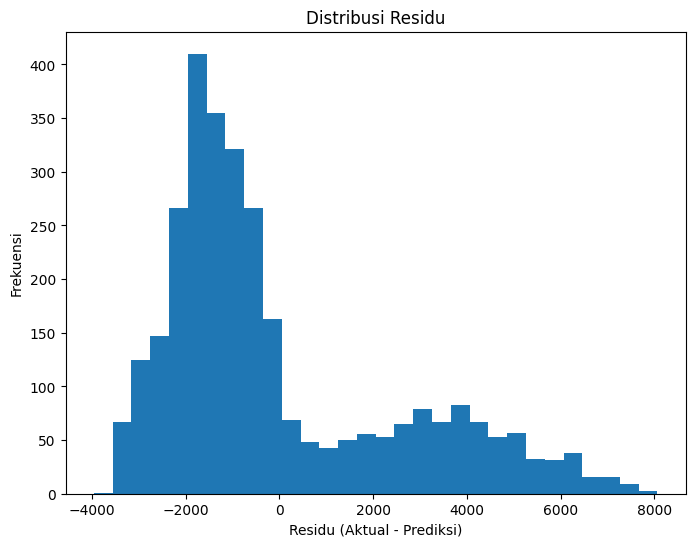

In [ ]:
residuals = y_test - y_pred
mean_residual = residuals.mean()

print(f"Rata-rata Residu: {mean_residual:.2f}")

# Optional: Plot the distribution of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30)
plt.title('Distribusi Residu')
plt.xlabel('Residu (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.show()

E. Evaluasi Model

In [ ]:
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

R²   : 0.10652855758786506
MAE  : 2064.2147790278746
RMSE : 2540.261477479446


F. Interpretasi Koefisien

In [ ]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
}).sort_values(by="Coefficient", ascending=False)

print(coef_df.head(15))
print(coef_df.tail(15))

               Feature  Coefficient
1                tahun   334.616900
0  kode_kabupaten_kota   -19.895211
               Feature  Coefficient
1                tahun   334.616900
0  kode_kabupaten_kota   -19.895211


Kategori pertanian dengan harga paling mahal dan lokasinya

/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 91.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 90.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 94.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 94.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 93.2% of the points cannot be plac

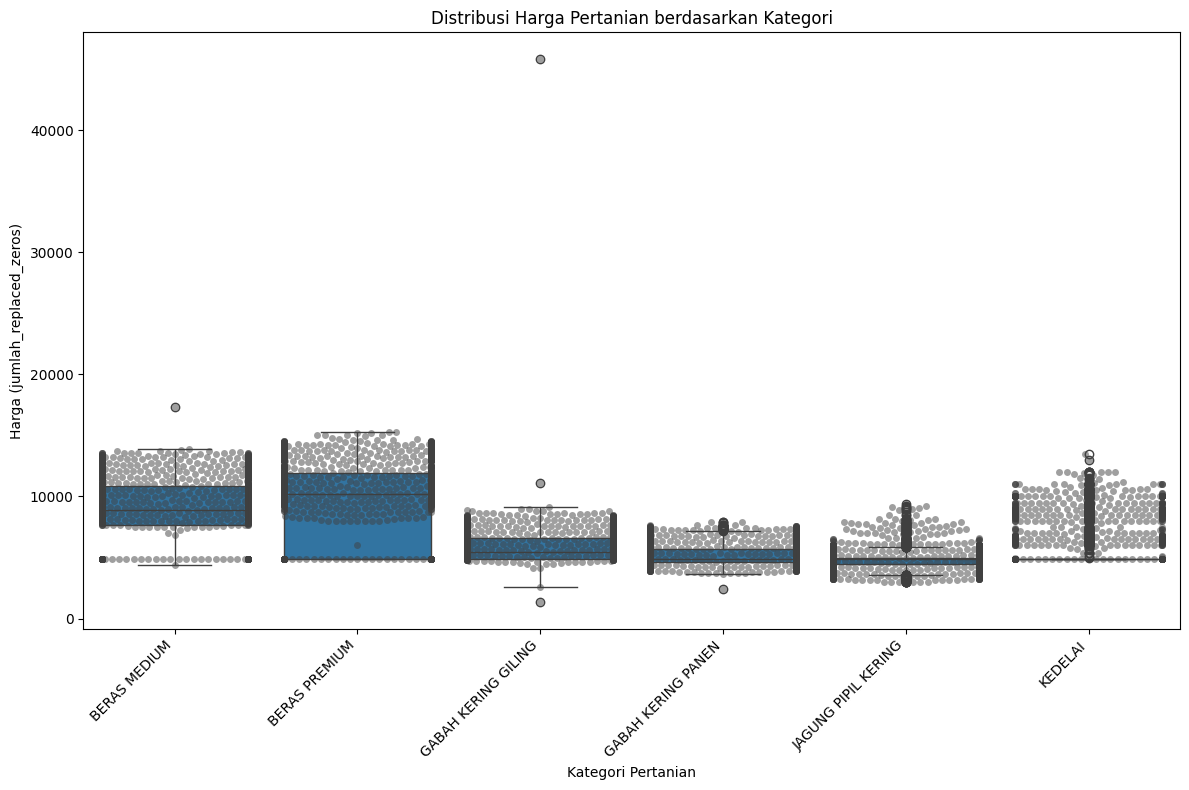

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8)) # Adjust figure size for better readability
sns.boxplot(x='kategori', y='jumlah_replaced_zeros', data=data)
sns.swarmplot(x='kategori', y='jumlah_replaced_zeros', data=data, color=".25", alpha=0.5) # Add swarm plot
plt.title('Distribusi Harga Pertanian berdasarkan Kategori')
plt.xlabel('Kategori Pertanian')
plt.ylabel('Harga (jumlah_replaced_zeros)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

In [ ]:
# Calculate descriptive statistics for 'jumlah_replaced_zeros' grouped by 'kategori'
category_price_stats = data.groupby('kategori')['jumlah_replaced_zeros'].describe()

print("Statistik Harga Pertanian berdasarkan Kategori:")
display(category_price_stats)

Statistik Harga Pertanian berdasarkan Kategori:


,count,mean,std,min,25%,50%,75%,max
kategori,,,,,,,,
BERAS MEDIUM,2546.0,8854.963472,2716.499842,4400.0,7650.00,8929.0,10849.75,17300.0
BERAS PREMIUM,2546.0,9540.930086,3314.537425,4851.0,4851.00,10200.0,11947.00,15250.0
GABAH KERING GILING,2546.0,5885.264336,1375.269194,1400.0,4851.00,5450.0,6621.75,45778.0
GABAH KERING PANEN,2546.0,5198.157895,902.444674,2390.0,4644.25,4851.0,5668.50,7924.0
JAGUNG PIPIL KERING,2546.0,4787.142577,725.981993,3000.0,4438.25,4851.0,5000.00,9375.0
KEDELAI,2546.0,5553.993716,1585.511134,4851.0,4851.00,4851.0,4851.00,13500.0


In [ ]:
# Group by kategori, nama_provinsi, nama_kabupaten_kota and find the maximum price
max_price_per_location_category = data.groupby(['kategori', 'nama_provinsi', 'nama_kabupaten_kota'])['jumlah_replaced_zeros'].max().reset_index()

# Find the row with the overall maximum price
highest_price_info = max_price_per_location_category.loc[max_price_per_location_category['jumlah_replaced_zeros'].idxmax()]

print("Kategori pertanian dengan harga paling mahal dan lokasinya:")
print(highest_price_info)

Kategori pertanian dengan harga paling mahal dan lokasinya:
kategori                 GABAH KERING GILING
nama_provinsi                     JAWA TIMUR
nama_kabupaten_kota          KABUPATEN NGAWI
jumlah_replaced_zeros                  45778
Name: 73, dtype: object


Perbandingan Harga Aktual vs Prediksi (Beberapa Baris Pertama):


,Actual Price,Predicted Price
13908,11414,8335.409846
14686,4840,6843.268989
10504,5900,7626.385623
3509,4851,6718.409286
4554,4851,5445.115755


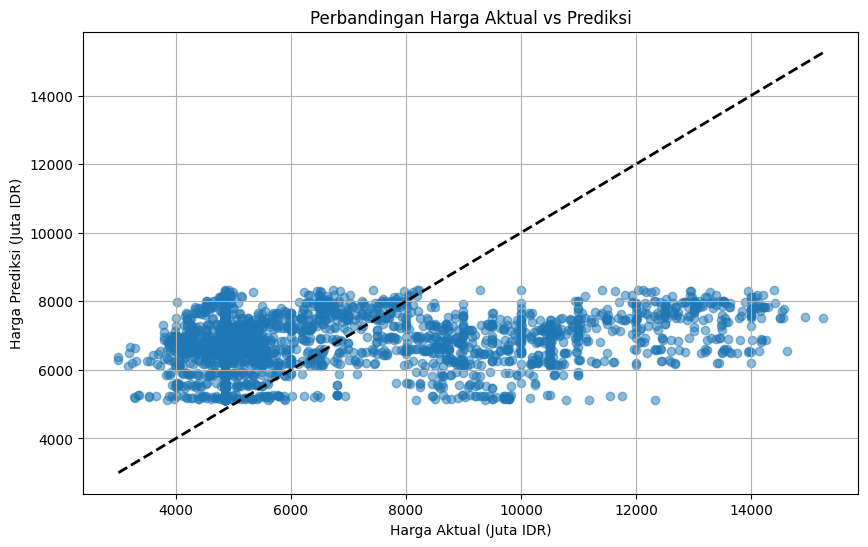

In [58]:
# Create a DataFrame to compare actual and predicted prices
predictions_vs_actual = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})

# Display the comparison
print("Perbandingan Harga Aktual vs Prediksi (Beberapa Baris Pertama):")
display(predictions_vs_actual.head())

# Create a scatter plot of actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(predictions_vs_actual['Actual Price'], predictions_vs_actual['Predicted Price'], alpha=0.5)
plt.title('Perbandingan Harga Aktual vs Prediksi')
plt.xlabel('Harga Aktual (Juta IDR)')
plt.ylabel('Harga Prediksi (Juta IDR)')
plt.grid(True)

# Add a line representing perfect predictions
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)

plt.show()

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import math

# Initialize and train the Linear Regression model with the new data
model = LinearRegression()
model.fit(X_train, y_train)
print("Linear Regression model trained successfully with new features.")

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = math.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation with New Features:")
print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

Linear Regression model trained successfully with new features.

Model Evaluation with New Features:
R²   : 0.5594377730645785
MAE  : 1285.4828410618718
RMSE : 1783.7817392131017


In [67]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Print the shapes of the resulting training and testing sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (12220, 7)
Shape of X_test: (3056, 7)
Shape of y_train: (12220,)
Shape of y_test: (3056,)
